# Why We Fit Curves in Python and Not in a Spreadsheet
**The data and boilerplate code were generated by Claude Opus 5 and modified by xli.**

**PHY 236 — Advanced Lab I Assignment #1**

A cup of coffee was left on a bench with a thermocouple in it. By recording its temperature every 2 minutes for an hour, we can measure the **cooling time constant** — how fast this cup loses heat.

**What to turn in:** this notebook with all cells run, plus your answers to the two questions at the end.

**If you want to save your own copy:** File -> Save a copy in Drive, and add your name or Coe ID to the file name.



---
## The physics

An object cooling in still air follows Newton's law of cooling:

$$T(t) = T_{\text{env}} + \Delta T\, e^{-t/\tau}$$

Three unknowns:

| symbol | meaning | units |
|---|---|---|
| $T_{\text{env}}$ | room temepature — given enough time the coffee will cool down to this value | °C |
| $\Delta T$ | how far above the room the coffee started | °C |
| $\tau$ | cooling time constant — time to close 63% of the remaining gap | min |

The quantity you actually want is $\tau$. Notice there's an extra term $T_{\text{env}}$ in the formula.

In [1]:
# Run this first.
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from io import StringIO

DATA = """t_min,T_C,sigma_y
0,86.96,0.3
2,81.70,0.3
4,76.32,0.3
6,71.31,0.3
8,66.77,0.3
10,63.06,0.3
12,59.54,0.3
14,56.31,0.3
16,53.19,0.3
18,50.86,0.3
20,47.53,0.3
22,45.86,0.3
24,43.37,0.3
26,41.27,0.3
28,40.06,0.3
30,38.10,0.3
32,36.50,0.3
34,34.96,0.3
36,34.48,0.3
38,33.44,0.3
40,31.70,0.3
42,31.51,0.3
44,30.67,0.3
46,29.97,0.3
48,28.54,0.3
50,28.40,0.3
52,27.62,0.3
54,27.97,0.3
56,26.98,0.3
58,26.13,0.3
60,25.71,0.3"""

t, T, sigma = np.loadtxt(StringIO(DATA), delimiter=",", skiprows=1, unpack=True)

print(f"{len(t)} readings, from t = {t[0]:.0f} to {t[-1]:.0f} min")
print(f"first reading: {T[0]:.2f} C     last reading: {T[-1]:.2f} C")
print(f"thermocouple uncertainty: +/- {sigma[0]} C on every point")

31 readings, from t = 0 to 60 min
first reading: 86.96 C     last reading: 25.71 C
thermocouple uncertainty: +/- 0.3 C on every point


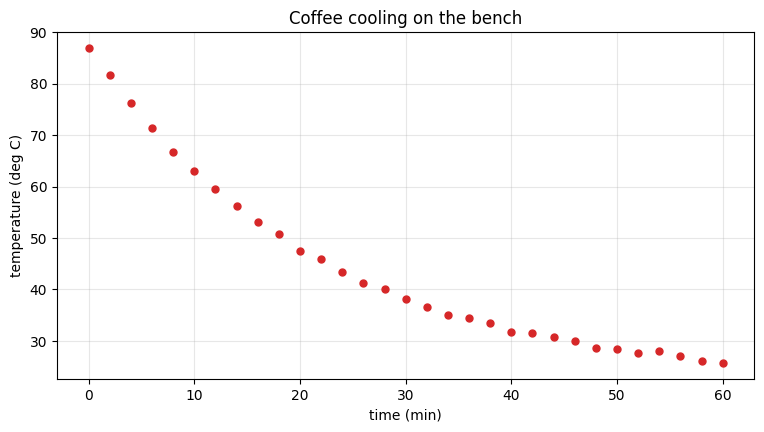

In [2]:
plt.figure(figsize=(9, 4.5))
plt.plot(t, T, 'o', ms=5, color='C3')
plt.xlabel('time (min)')
plt.ylabel('temperature (deg C)')
plt.title('Coffee cooling on the bench')
plt.grid(alpha=0.3)
plt.show()

---
## Part 1 — In Excel or Spreadsheet

Excel's built-in exponential trendline fits

$$y = a\,e^{bx}$$

As there is nowhere to put $T_{\text{env}}$, the standard workaround is to make a guess then subtract the room temperature, and fit the "offset data". In a spreadsheet you would make a new column `=B2-21` and put a trendline on that.

This guess will induce error. The cell below runs exactly that workaround for several guesses. It does the same exponential trendline fits as an excel sheet would do.

In [5]:
print("  assumed room temp     tau you would report")
for T_assumed in [18.0, 20.0, 23.0, 25.0]:
    slope, intercept = np.polyfit(t, np.log(T - T_assumed), 1)
    print(f"{T_assumed:12.1f} C {-1/slope:22.1f} min")

  assumed room temp     tau you would report
        18.0 C                   27.4 min
        20.0 C                   24.5 min
        23.0 C                   19.7 min
        25.0 C                   15.5 min


---
### This is one way to corrupt your data

If you guess the room temperature to be 18 °C instead of 25 °C, your "measurment" for $\tau$ will be changed by nearly a factor of two.

No matter which room temperature you pick, every fitted curve will have an R-squared above 0.99.

Can you find the real $T_{\text{env}}$ without assuming? The value should be in the data, right?

> *An honest footnote:* Excel's Solver add-in can do a genuine three-parameter nonlinear fit. But it has to be enabled, set up cell by cell, and re-done by hand for every new data set.

---
## Part 2 — Fit all three parameters at once

`curve_fit` takes a Python function of any shape you like. You write the physics; it finds the parameter values that best match the data.

Two things to fill in below:

1. **The model function.** Translate $T(t) = T_{\text{env}} + \Delta T\,e^{-t/\tau}$ into Python. Use `np.exp`.
2. **A rough starting guess** `p0`. It does not need to be good — read the numbers off your plot. Roughly what does the curve level off toward? How far above that did it start? Roughly how long did it take to fall most of the way?

In [14]:
def cooling(t, T_env, dT, tau):
    return #TODO: write out the model function here, with T_env, dT, t and tau. For the exp function, you need to use np.exp.


# TODO: rough starting guesses, replacing the followng "None" wiht values for T_env, dT, tau (tau is already filled as 15.0, but feel free to modify the value).
p0 = [None, None, 15.0]

popt, pcov = curve_fit(cooling, t, T, p0=p0, sigma=sigma, absolute_sigma=True)
perr = np.sqrt(np.diag(pcov))   # uncertainty on each fitted parameter

for name, val, err, unit in zip(['T_env', 'dT', 'tau'], popt, perr, ['C', 'C', 'min']):
    print(f"{name:>6} = {val:7.2f} +/- {err:.2f} {unit}")

TypeError: unsupported operand type(s) for -: 'NoneType' and 'float'

That is the entire fit. Three parameters, uncertainties on all of them, no guessing.

Note what you got for free: **`T_env` is now a measurement.** The coffee never actually reached room temperature during the hour you watched it, but the shape of the curve tells you where it was headed. You measured the temperature of the room using a cup of coffee. A spreadsheet trendline cannot do that, because it made you supply that number before it would start.

ValueError: x, y, and format string must not be None

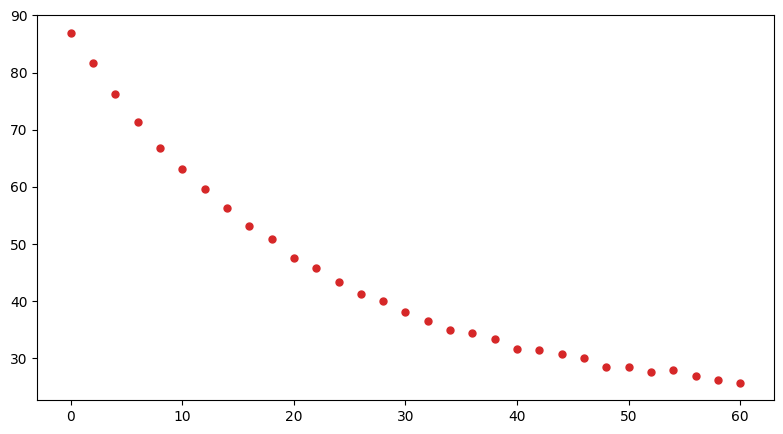

In [15]:
tt = np.linspace(0, 75, 400)

plt.figure(figsize=(9.5, 5))
plt.plot(t, T, 'o', ms=5, color='C3', label='data', zorder=5)
plt.plot(tt, cooling(tt, *popt), 'C0-', lw=2, label='Python fit (all 3 parameters)')

for T_assumed, style in [(0.0, ':'), (25.0, '--')]:
    slope, intercept = np.polyfit(t, np.log(T - T_assumed), 1)
    curve = T_assumed + np.exp(intercept) * np.exp(slope * tt)
    plt.plot(tt, curve, style, lw=1.4, color='0.35',
             label=f'spreadsheet, room assumed {T_assumed:.0f} C')

plt.axhline(popt[0], color='C0', lw=0.9, alpha=0.5)
plt.text(70, popt[0] + 1.2, 'fitted room temp', color='C0', ha='right', fontsize=9)
plt.xlabel('time (min)'); plt.ylabel('temperature (deg C)')
plt.legend(); plt.grid(alpha=0.3)
plt.title('Curve fitting comparation between three methods')
plt.show()

---
## Part 3 — One quick sanity check

You should never trust a fit just because the curve looks about right. The fastest honest check is a **residual plot**: the gap between each data point and the fitted curve.

If the model is right, those gaps scatter randomly above and below zero.

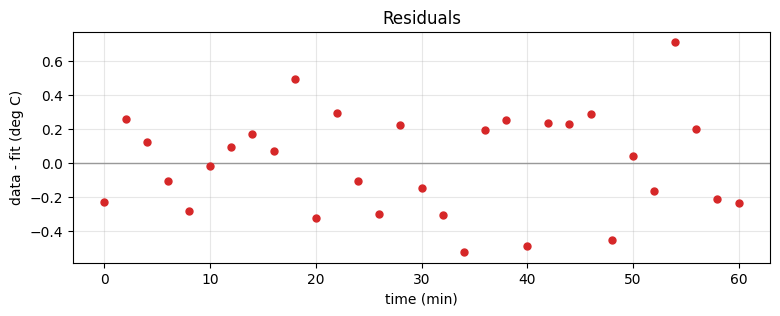

typical size of residuals: 0.29 C
thermocouple uncertainty:  0.30 C


In [12]:
residuals = T - cooling(t, *popt)

plt.figure(figsize=(9, 3))
plt.axhline(0, color='0.6', lw=1)
plt.plot(t, residuals, 'o', ms=5, color='C3')
plt.xlabel('time (min)'); plt.ylabel('data - fit (deg C)')
plt.title('Residuals')
plt.grid(alpha=0.3)
plt.show()

print(f"typical size of residuals: {residuals.std():.2f} C")
print(f"thermocouple uncertainty:  {sigma[0]:.2f} C")

**Compare the residual value.** If the scatter of your residuals is about the same size as the thermocouple's stated uncertainty, then your curve fitting is a success.

---
## Questions

Type your answers directly under each one (double-click this cell to edit).

**1.** Using the table from Part 1, how much did $\tau$ change between assuming the room was 18 °C and assuming it was 25 °C? Express it as a percentage of your Python answer.

**2.** Every one of those spreadsheet fits would have given R-squared above 0.99. In one or two sentences: why is a high R-squared not evidence that an answer is correct?


---
## Before you submit

- [ ] Runtime -> Restart and run all, with no errors
- [ ] `tau` reported with its uncertainty and units
- [ ] The three-curve comparison plot is showing
- [ ] Residual plot shown, and you compared its scatter to the thermocouple uncertainty
- [ ] All two questions answered in your own words